## Load

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from src.config import FEATURES_CSV
df = pd.read_csv(FEATURES_CSV)
df.head()

,pdb_id,protein,variant,morphology,n_protofilaments,label,source,notes,length,frac_hydrophobic,...,plddt_mean,plddt_median,frac_disordered,ss_helix,ss_sheet,ss_coil,sasa_total,sasa_hydrophobic,sasa_polar,sasa_hydrophobic_frac
0,7Q4B,Amyloid-beta,Abeta42,single,1,0,Brain-derived,Type I brain-derived fold,42,0.476190,...,NaN,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377
1,2NAO,Amyloid-beta,Abeta42,multi,2,1,In vitro NMR,Double-horseshoe doublet,42,0.476190,...,NaN,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377
2,6W06,Amyloid-beta,Abeta40,single,1,0,In vitro,Single protofilament,293,0.412969,...,NaN,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377
3,2M4J,Amyloid-beta,Abeta40,multi,3,1,In vitro NMR,3-fold symmetric triplet,40,0.450000,...,NaN,NaN,0.0,0.376623,0.171429,0.451948,70481.609820,21875.868545,48605.741275,0.310377
4,8RRR,Alpha-synuclein,WT,single,1,0,Brain-derived,Lewy fold,140,0.385714,...,NaN,NaN,0.0,0.650000,0.000000,0.350000,14827.285542,5715.487502,9111.798040,0.385471


## Sanity check feature distributions by class

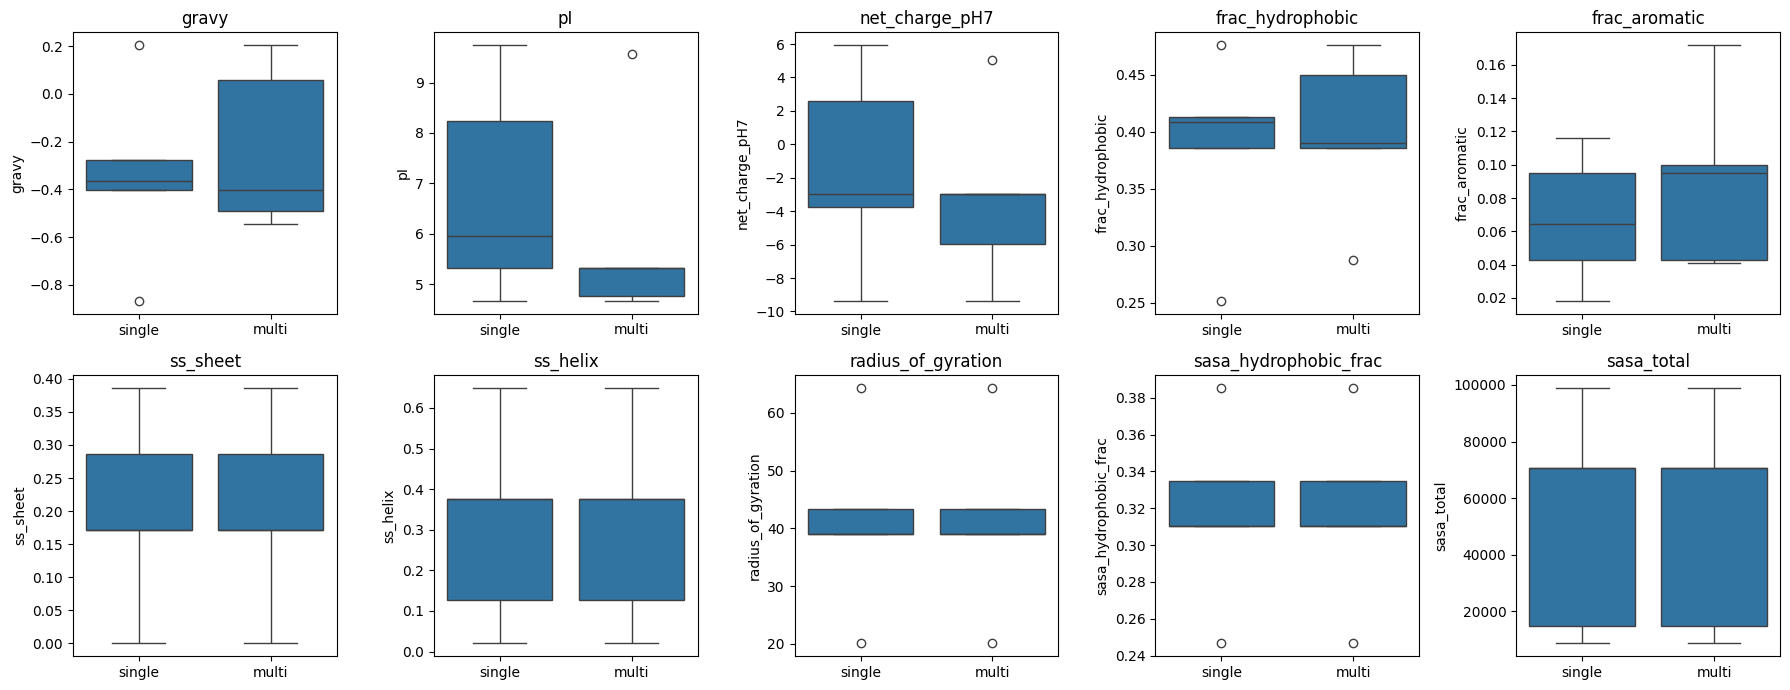

In [2]:
feature_cols = [
    # Physicochemical (§5)
    "gravy",
    "pI",
    "net_charge_pH7",
    "frac_hydrophobic",
    "frac_aromatic",
    # Structural — secondary structure & geometry (§5)
    "ss_sheet",
    "ss_helix",
    "radius_of_gyration",
    # Structural — solvent accessibility (§5)
    "sasa_hydrophobic_frac",
    "sasa_total",
]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x="morphology", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../results/feature_distributions.png", dpi=150)

## Correlation heatmap

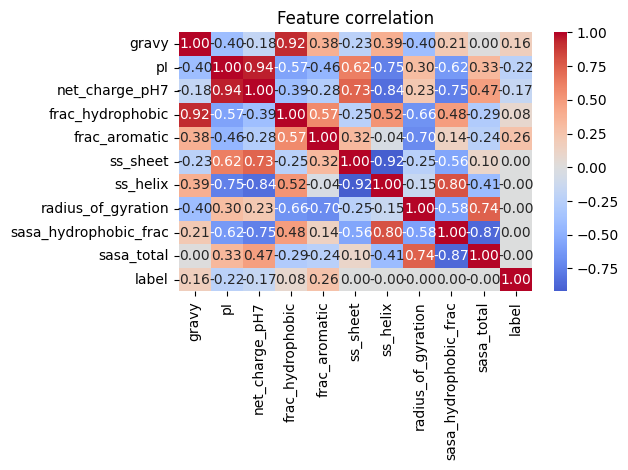

In [3]:
import numpy as np
num = df[feature_cols + ["label"]].dropna()
sns.heatmap(num.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Feature correlation"); plt.tight_layout()
plt.savefig("../results/feature_correlation.png", dpi=150)